In [5]:
import polars as pl
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import os 

train_data_pl = pl.read_csv(r"../data/train.csv",encoding="shift_jis")

In [6]:
import mlflow

In [7]:

from FeatureEngineer import FeatureEngineer
from FullPipelineModel import FullPipelineModel
from MoisturePipeline import MoisturePipeline

In [14]:
with mlflow.start_run() as run:
    pipe_path = "pipe.pkl"

    pipe = MoisturePipeline(
        use_pca=False,
        use_diff=False,
        use_conv=False,
        use_band=False,
        use_sg=False,
        params={
        "verbosity": -1,
        "n_estimators": 1000,
        "learning_rate": 0.03,
        "num_leaves": 6,
        "max_depth": 3,
        "min_data_in_leaf": 30,   #重要
        "feature_fraction": 0.7,
        "bagging_fraction": 0.7,
        "bagging_freq": 1,
        "n_jobs": -1,
        }
    )

    rmse = pipe.fit(train_data_pl)

    with open("pipe.pkl", "wb") as f:#保存用
        pickle.dump(pipe, f)
        
    assert os.path.exists(pipe_path)
    
    mlflow.log_artifact(pipe_path)
    mlflow.log_params({
        **pipe.params,
        "use_conv": pipe.use_conv,
        "use_diff": pipe.use_diff,
        "use_band": pipe.use_band,
        "use_pca": pipe.use_pca,
    })
    mlflow.log_metric("rmse", rmse)

    
    mlflow.pyfunc.log_model(
        python_model=FullPipelineModel(None),
        artifact_path="model",
        artifacts={"pipe": pipe_path}
    )

    
    """
    try:
        mlflow.pyfunc.log_model(
            name="model",
            python_model=FullPipelineModel(None),
            #artifact_path="model",
            artifacts={"pipe": pipe_path}
        )
    except:
        print("ERRROERRRRRRRRR!!!!!!")
        print("run_id:", run.info.run_id)
    """

Distutils was imported before Setuptools, but importing Setuptools also replaces the `distutils` module in `sys.modules`. This may lead to undesirable behaviors or errors. To avoid these issues, avoid using distutils directly, ensure that setuptools is installed in the traditional way (e.g. not an editable install), and/or make sure that setuptools is always imported before distutils.
Setuptools is replacing distutils. Support for replacing an already imported distutils is deprecated. In the future, this condition will fail. Register concerns at https://github.com/pypa/setuptools/issues/new?template=distutils-deprecation.yml


In [12]:
run_id = run.info.run_id
print(run_id)

6e82d9db807247e6b533af4218b73124


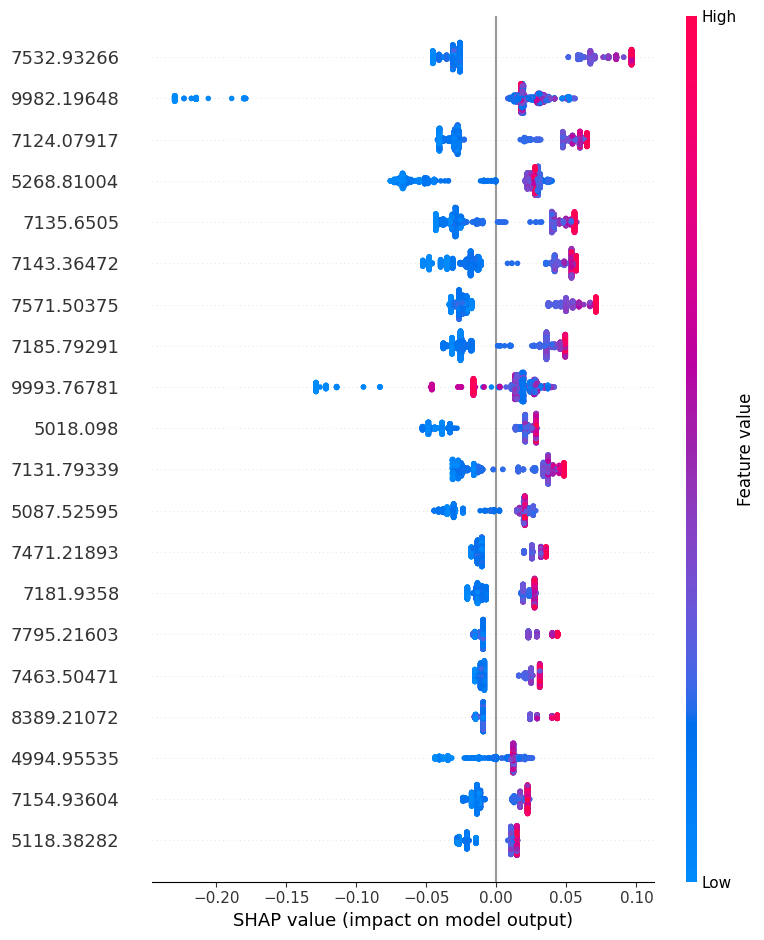


=== SHAP importance ===
7532.93266    0.047457
9982.19648    0.042915
7124.07917    0.039372
5268.81004    0.037545
7135.6505     0.036746
7143.36472    0.035604
7571.50375    0.035361
7185.79291    0.032227
9993.76781    0.031246
5018.098      0.029576
7131.79339    0.029409
5087.52595    0.023655
7471.21893    0.018830
7181.9358     0.017406
7795.21603    0.016941
7463.50471    0.016619
8389.21072    0.016567
4994.95535    0.016509
7154.93604    0.016153
5118.38282    0.015950
dtype: float64


In [13]:
from ml_pipeline import FeatureEngineer  # 定義している場所からimport

# SHAP可視化

shap_importance = pipe.fe.show_shap(train_data_pl, pipe.model, pipe.feature_cols)

#pipe.fe.show_shap(train_data_pl, pipe.model, pipe.feature_cols)